In [86]:
# ============================================
# INSTALL & IMPORT
# ============================================

# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn tensorflow pytorch-tabnet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN

import tensorflow as tf
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Input, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

from pytorch_tabnet.tab_model import TabNetClassifier

import os
import pickle
import json
import time

print("✅ Library berhasil diimport")
print(f"TensorFlow version: {tf.__version__}")

✅ Library berhasil diimport
TensorFlow version: 2.21.0


In [87]:
# ============================================
# FOCAL LOSS FUNCTION
# ============================================

def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss untuk mengatasi class imbalance
    FL(p_t) = -α(1-p_t)^γ log(p_t)
    """
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma) * y_true + (1 - alpha) * tf.pow(y_pred, gamma) * (1 - y_true)
        return tf.reduce_mean(weight * cross_entropy)
    return focal_loss_fixed

print("✅ Focal Loss function siap")

✅ Focal Loss function siap


In [88]:
# ============================================
# LOAD DATASET 
# ============================================

possible_paths = [
    '../data/HR_comma_sep.csv',
    'data/HR_comma_sep.csv',
    'HR_comma_sep.csv',
]

DATA_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    print("❌ Dataset tidak ditemukan!")
else:
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

df.head()

✅ Dataset loaded: 14999 rows, 10 columns


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


EKSPLORASI & PREPROCESSING

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB

Missing Values:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_a

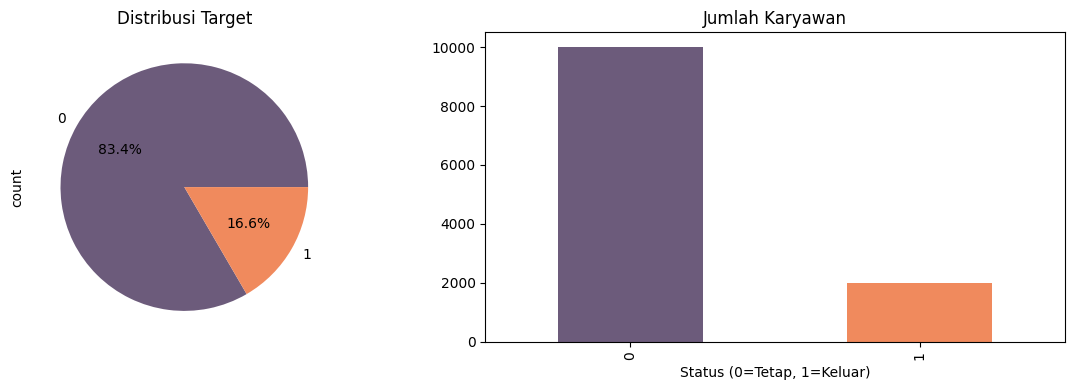


X shape: (11991, 9)
y shape: (11991,)


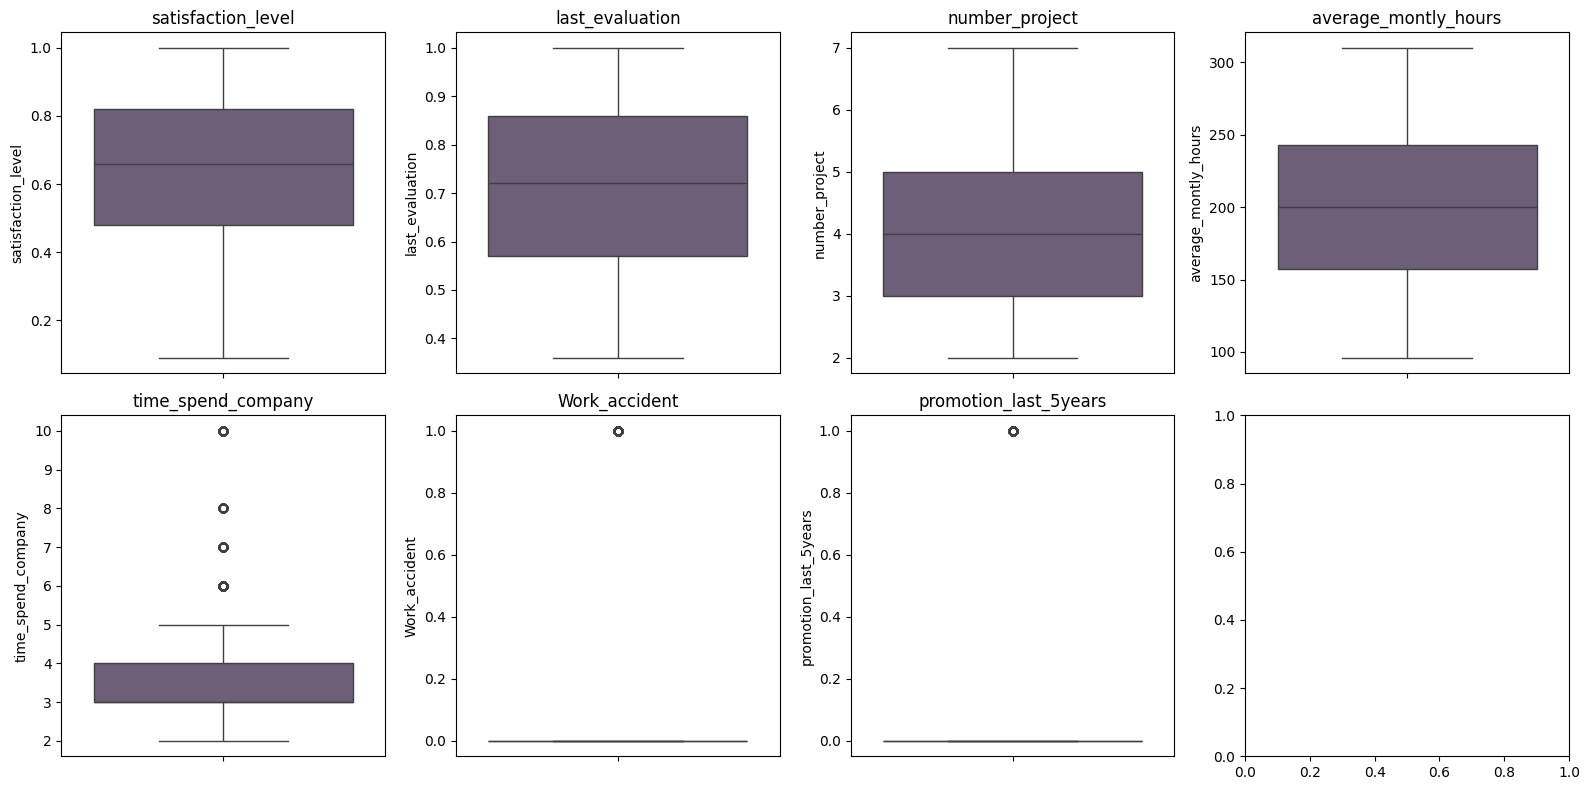


Outlier Handling dengan Winsorizing...
   time_spend_company: 824 outlier di-winsorize
   Work_accident: 1850 outlier di-winsorize
   promotion_last_5years: 203 outlier di-winsorize

Fitur Kategorikal: ['sales', 'salary']
   sales encoded
   salary encoded

Total fitur setelah encoding: 9


In [89]:
# ============================================
# EKSPLORASI & PREPROCESSING
# ============================================

print("=" * 60)
print("EKSPLORASI & PREPROCESSING")
print("=" * 60)

print("\nInformasi Dataset:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDistribusi Target (left):")
print(df['left'].value_counts())
print(df['left'].value_counts(normalize=True) * 100)

# Cek duplikat
duplicates = df.duplicated().sum()
print(f"\nDuplikat: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"   Setelah drop: {df.shape[0]} rows")

# Visualisasi target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['left'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], colors=['#6c5b7b', '#f08a5d'])
axes[0].set_title('Distribusi Target')
df['left'].value_counts().plot.bar(ax=axes[1], color=['#6c5b7b', '#f08a5d'])
axes[1].set_title('Jumlah Karyawan')
axes[1].set_xlabel('Status (0=Tetap, 1=Keluar)')
plt.tight_layout()
plt.show()

# Pisahkan fitur dan target
target = 'left'
y = df[target].copy()
X = df.drop(columns=[target]).copy()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# Cek outlier (visual)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
for i, col in enumerate(numeric_cols[:8]):
    sns.boxplot(y=X[col], ax=axes[i//4, i%4], color='#6c5b7b')
    axes[i//4, i%4].set_title(col)
plt.tight_layout()
plt.show()

# Handling outlier dengan Winsorizing
print("\nOutlier Handling dengan Winsorizing...")
for col in numeric_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((X[col] < lower_bound) | (X[col] > upper_bound)).sum()
    if outliers > 0:
        X[col] = X[col].clip(lower_bound, upper_bound)
        print(f"   {col}: {outliers} outlier di-winsorize")

# Encoding kategorikal
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nFitur Kategorikal: {categorical_cols}")

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le
    print(f"   {col} encoded")

print(f"\nTotal fitur setelah encoding: {X.shape[1]}")

In [90]:
# ============================================
# DATA SPLITTING (80/10/10)
# ============================================

print("=" * 60)
print("DATA SPLITTING (80/10/10)")
print("=" * 60)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp
)

print(f"\nTraining Set   : {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation Set : {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Testing Set    : {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

print("\nDistribusi di Training Set:")
print(f"   Tetap (0): {len(y_train) - y_train.sum()}")
print(f"   Keluar (1): {y_train.sum()} ({y_train.sum()/len(y_train)*100:.2f}%)")

DATA SPLITTING (80/10/10)

Training Set   : 9592 samples (80.0%)
Validation Set : 1199 samples (10.0%)
Testing Set    : 1200 samples (10.0%)

Distribusi di Training Set:
   Tetap (0): 7999
   Keluar (1): 1593 (16.61%)


In [91]:
# ============================================
# STANDARISASI
# ============================================

print("=" * 60)
print("STANDARISASI DATA")
print("=" * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data telah distandarisasi")
print(f"X_train_scaled shape: {X_train_scaled.shape}")

STANDARISASI DATA
✅ Data telah distandarisasi
X_train_scaled shape: (9592, 9)


In [92]:
# ============================================
# HANDLING IMBALANCE - 3 SKENARIO
# ============================================

print("=" * 60)
print("HANDLING IMBALANCE - 3 SKENARIO")
print("=" * 60)

# SKENARIO 1: NO HANDLING
print("\n[1] NO HANDLING (Baseline)")
print(f"   Training: {len(y_train)} samples (IMBALANCED)")
print(f"   Keluar (1): {y_train.sum()} ({y_train.sum()/len(y_train)*100:.2f}%)")

# SKENARIO 2: SMOTE-ENN
print("\n[2] SMOTE-ENN")
smote_enn = SMOTEENN(random_state=42)
X_train_smote, y_train_smote = smote_enn.fit_resample(X_train_scaled, y_train)
print(f"   Sebelum: {len(y_train)} samples")
print(f"   Setelah: {len(X_train_smote)} samples")
print(f"   Keluar (1): {y_train_smote.sum()} ({y_train_smote.sum()/len(y_train_smote)*100:.2f}%)")

# SKENARIO 3: CLASS WEIGHT
class_weight = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weight))
print("\n[3] CLASS WEIGHT")
print(f"   Class Weight: {class_weight_dict}")
print(f"   Training: {len(y_train)} samples (TETAP IMBALANCED)")

print("\nValidation Set: TETAP IMBALANCED")
print(f"   Keluar (1): {y_val.sum()} ({y_val.sum()/len(y_val)*100:.2f}%)")
print("Testing Set: TETAP IMBALANCED")
print(f"   Keluar (1): {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")

HANDLING IMBALANCE - 3 SKENARIO

[1] NO HANDLING (Baseline)
   Training: 9592 samples (IMBALANCED)
   Keluar (1): 1593 (16.61%)

[2] SMOTE-ENN
   Sebelum: 9592 samples
   Setelah: 15074 samples
   Keluar (1): 7784 (51.64%)

[3] CLASS WEIGHT
   Class Weight: {np.int64(0): np.float64(0.5995749468683585), np.int64(1): np.float64(3.01067168863779)}
   Training: 9592 samples (TETAP IMBALANCED)

Validation Set: TETAP IMBALANCED
   Keluar (1): 199 (16.60%)
Testing Set: TETAP IMBALANCED
   Keluar (1): 199 (16.58%)


In [93]:
# ============================================
# FUNGSI BUILD MODEL
# ============================================

def build_mlp_deep_focal(input_dim):
    """
    MLP Deep + Focal Loss
    Arsitektur lebih dalam dengan 4 hidden layers
    """
    inputs = Input(shape=(input_dim,))
    x = inputs
    
    # Layer 1: 256 units
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    # Layer 2: 128 units
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    # Layer 3: 64 units
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    # Layer 4: 32 units
    x = Dense(32, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )
    return model

def build_mlp_modern(input_dim):
    """
    MLP Modern (3 layers) untuk perbandingan
    """
    inputs = Input(shape=(input_dim,))
    x = inputs
    
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    x = Dense(32, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def get_tabnet_params():
    return {
        'n_d': 64,
        'n_a': 64,
        'n_steps': 5,
        'gamma': 1.5,
        'lambda_sparse': 0.001,
        'mask_type': 'sparsemax',
        'verbose': 0
    }

print("✅ Fungsi build model siap")

✅ Fungsi build model siap


In [94]:
# ============================================
# TRAINING - 6 KOMBINASI
# ============================================

print("=" * 60)
print("TRAINING - 6 KOMBINASI")
print("=" * 60)

all_results = {}
input_dim = X_train_scaled.shape[1]
EPOCHS = 150
BATCH_SIZE = 32
EPOCHS_TABNET = 100
BATCH_SIZE_TABNET = 512
VIRTUAL_BATCH_SIZE = 128

# ============================================
# 1. MLP Modern + No Handling
# ============================================
print("\n[1] MLP Modern + No Handling")
model_mlp_nh = build_mlp_modern(input_dim)
start = time.time()
history_mlp_nh = model_mlp_nh.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, monitor='val_loss')],
    verbose=1
)
time_mlp_nh = time.time() - start

y_pred = (model_mlp_nh.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
y_prob = model_mlp_nh.predict(X_test_scaled, verbose=0)
all_results['MLP_NoHandling'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_prob),
    'training_time': time_mlp_nh
}

# ============================================
# 2. MLP Modern + Class Weight
# ============================================
print("\n[2] MLP Modern + Class Weight")
model_mlp_cw = build_mlp_modern(input_dim)
start = time.time()
history_mlp_cw = model_mlp_cw.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, monitor='val_loss')],
    verbose=1
)
time_mlp_cw = time.time() - start

y_pred = (model_mlp_cw.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
y_prob = model_mlp_cw.predict(X_test_scaled, verbose=0)
all_results['MLP_ClassWeight'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_prob),
    'training_time': time_mlp_cw
}

# ============================================
# 3. MLP Deep + Focal Loss + SMOTE-ENN
# ============================================
print("\n[3] MLP Deep + Focal Loss + SMOTE-ENN")
model_mlp_focal = build_mlp_deep_focal(input_dim)
start = time.time()
history_mlp_focal = model_mlp_focal.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6, monitor='val_loss')],
    verbose=1
)
time_mlp_focal = time.time() - start

y_pred = (model_mlp_focal.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
y_prob = model_mlp_focal.predict(X_test_scaled, verbose=0)
all_results['MLP_Deep_FocalLoss_SMOTE'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_prob),
    'training_time': time_mlp_focal
}

# ============================================
# 4. TabNet + No Handling
# ============================================
print("\n[4] TabNet + No Handling")
tabnet_nh = TabNetClassifier(**get_tabnet_params())
start = time.time()
tabnet_nh.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=EPOCHS_TABNET,
    patience=EPOCHS_TABNET,
    batch_size=BATCH_SIZE_TABNET,
    virtual_batch_size=VIRTUAL_BATCH_SIZE,
    num_workers=0,
    drop_last=False
)
time_tabnet_nh = time.time() - start

y_pred = tabnet_nh.predict(X_test_scaled)
y_prob = tabnet_nh.predict_proba(X_test_scaled)[:, 1]
all_results['TabNet_NoHandling'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_prob),
    'training_time': time_tabnet_nh
}

# ============================================
# 5. TabNet + SMOTE-ENN
# ============================================
print("\n[5] TabNet + SMOTE-ENN")
tabnet_smote = TabNetClassifier(**get_tabnet_params())
start = time.time()
tabnet_smote.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_val_scaled, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=EPOCHS_TABNET,
    patience=EPOCHS_TABNET,
    batch_size=BATCH_SIZE_TABNET,
    virtual_batch_size=VIRTUAL_BATCH_SIZE,
    num_workers=0,
    drop_last=False
)
time_tabnet_smote = time.time() - start

y_pred = tabnet_smote.predict(X_test_scaled)
y_prob = tabnet_smote.predict_proba(X_test_scaled)[:, 1]
all_results['TabNet_SMOTE_ENN'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_prob),
    'training_time': time_tabnet_smote
}

# ============================================
# 6. TabNet + SMOTE-ENN + Focal (duplikasi)
# ============================================
print("\n[6] TabNet + SMOTE-ENN + Focal (duplikasi fraud)")
fraud_indices = np.where(y_train_smote == 1)[0]
fraud_X = X_train_smote[fraud_indices]
fraud_y = y_train_smote[fraud_indices]

X_train_weighted = np.vstack([X_train_smote, fraud_X])
y_train_weighted = np.hstack([y_train_smote, fraud_y])

tabnet_focal = TabNetClassifier(**get_tabnet_params())
start = time.time()
tabnet_focal.fit(
    X_train_weighted, y_train_weighted,
    eval_set=[(X_val_scaled, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=EPOCHS_TABNET,
    patience=EPOCHS_TABNET,
    batch_size=BATCH_SIZE_TABNET,
    virtual_batch_size=VIRTUAL_BATCH_SIZE,
    num_workers=0,
    drop_last=False
)
time_tabnet_focal = time.time() - start

y_pred = tabnet_focal.predict(X_test_scaled)
y_prob = tabnet_focal.predict_proba(X_test_scaled)[:, 1]
all_results['TabNet_FocalLoss_SMOTE'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_prob),
    'training_time': time_tabnet_focal
}

print("\n✅ Semua training selesai!")

TRAINING - 6 KOMBINASI

[1] MLP Modern + No Handling
Epoch 1/150
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7992 - loss: 0.4635 - val_accuracy: 0.9600 - val_loss: 0.1733 - learning_rate: 0.0010
Epoch 2/150
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9185 - loss: 0.2315 - val_accuracy: 0.9633 - val_loss: 0.1138 - learning_rate: 0.0010
Epoch 3/150
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9331 - loss: 0.1965 - val_accuracy: 0.9650 - val_loss: 0.1109 - learning_rate: 0.0010
Epoch 4/150
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9461 - loss: 0.1683 - val_accuracy: 0.9708 - val_loss: 0.0912 - learning_rate: 0.0010
Epoch 5/150
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9446 - loss: 0.1691 - val_accuracy: 0.9725 - val_loss: 0.0884 - learning_rate: 0.0010
Epoch 6/150
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9503 - loss: 0.1560 - val_accuracy: 0.9708 - val_loss: 0.0887 - learning_rate: 0.0010
Epoch 7/150
300/300 ━━━━━━━━━

In [95]:
# ============================================
# PERBANDINGAN 6 KOMBINASI
# ============================================

print("=" * 60)
print("PERBANDINGAN 6 KOMBINASI")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Kombinasi': list(all_results.keys()),
    'Model': [k.split('_')[0] for k in all_results.keys()],
    'Imbalance': [k.split('_')[1] if len(k.split('_')) > 1 else 'Unknown' for k in all_results.keys()],
    'Accuracy': [r['accuracy'] for r in all_results.values()],
    'Precision': [r['precision'] for r in all_results.values()],
    'Recall': [r['recall'] for r in all_results.values()],
    'F1-Score': [r['f1'] for r in all_results.values()],
    'AUC-ROC': [r['auc'] for r in all_results.values()],
    'Training Time (s)': [r['training_time'] for r in all_results.values()]
})

comparison_df = comparison_df.sort_values('F1-Score', ascending=False)
display(comparison_df)

# Simpan ke CSV
os.makedirs('../models', exist_ok=True)
comparison_df.to_csv('../models/comparison_results.csv', index=False)
print("\n✅ Hasil perbandingan disimpan di: models/comparison_results.csv")

PERBANDINGAN 6 KOMBINASI


,Kombinasi,Model,Imbalance,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Training Time (s)
0,MLP_NoHandling,MLP,NoHandling,0.975833,0.956989,0.894472,0.924675,0.970562,65.445663
1,MLP_ClassWeight,MLP,ClassWeight,0.968333,0.900498,0.909548,0.905000,0.969423,72.098122
4,TabNet_SMOTE_ENN,TabNet,SMOTE,0.949167,0.805310,0.914573,0.856471,0.958403,141.638981
3,TabNet_NoHandling,TabNet,NoHandling,0.951667,0.847291,0.864322,0.855721,0.940120,89.523193
5,TabNet_FocalLoss_SMOTE,TabNet,FocalLoss,0.916667,0.685393,0.919598,0.785408,0.963813,226.552330
2,MLP_Deep_FocalLoss_SMOTE,MLP,Deep,0.310000,0.193171,0.994975,0.323529,0.909390,116.796531



✅ Hasil perbandingan disimpan di: models/comparison_results.csv


✅ Plot disimpan di: models/comparison_plot.png


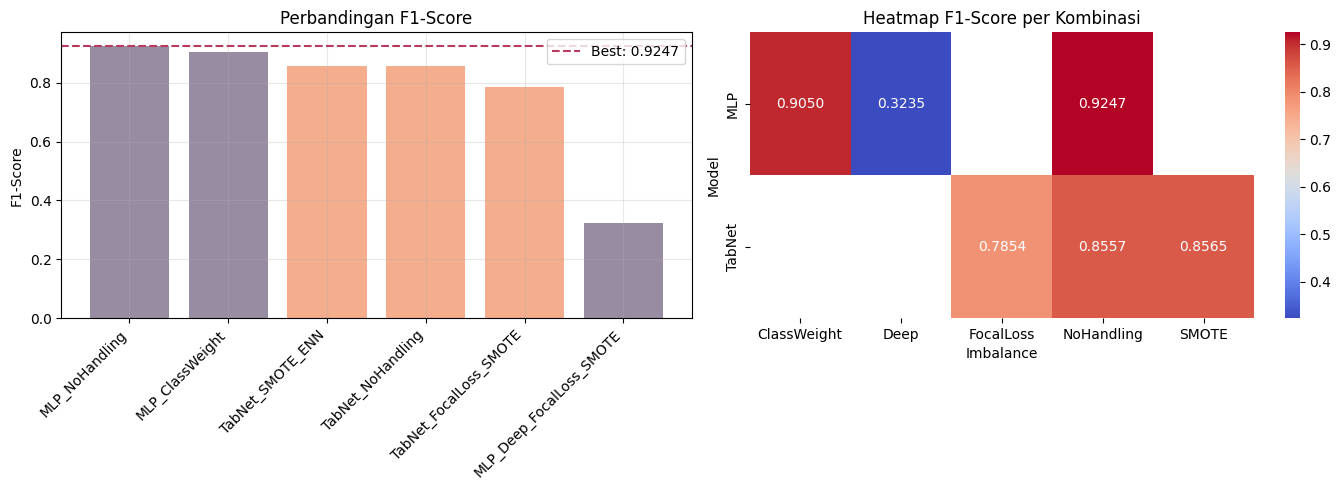

In [96]:
# ============================================
# VISUALISASI PERBANDINGAN
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart F1-Score
colors = ['#6c5b7b' if 'MLP' in k else '#f08a5d' for k in comparison_df['Kombinasi']]
bars = axes[0].bar(comparison_df['Kombinasi'], comparison_df['F1-Score'], color=colors, alpha=0.7)
axes[0].set_xticklabels(comparison_df['Kombinasi'], rotation=45, ha='right')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Perbandingan F1-Score')
axes[0].axhline(y=comparison_df['F1-Score'].max(), color='#b83b5e', linestyle='--', 
                label=f"Best: {comparison_df['F1-Score'].max():.4f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Heatmap
pivot = comparison_df.pivot_table(index='Model', columns='Imbalance', values='F1-Score')
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Heatmap F1-Score per Kombinasi')

plt.tight_layout()
plt.savefig('../models/comparison_plot.png', dpi=150)
print("✅ Plot disimpan di: models/comparison_plot.png")
plt.show()

In [97]:
# ============================================
# SIMPAN MODEL TERBAIK
# ============================================

print("=" * 60)
print("SIMPAN MODEL TERBAIK")
print("=" * 60)

best_key = comparison_df.iloc[0]['Kombinasi']
best_f1 = comparison_df.iloc[0]['F1-Score']
best_acc = comparison_df.iloc[0]['Accuracy']
best_recall = comparison_df.iloc[0]['Recall']

print(f"🏆 Model Terbaik: {best_key}")
print(f"   F1-Score: {best_f1:.4f}")
print(f"   Accuracy: {best_acc:.4f}")
print(f"   Recall: {best_recall:.4f}")

# Pilih model terbaik
if 'MLP_Deep_FocalLoss' in best_key:
    best_model = model_mlp_focal
elif 'MLP_NoHandling' in best_key:
    best_model = model_mlp_nh
elif 'MLP_ClassWeight' in best_key:
    best_model = model_mlp_cw
elif 'TabNet_FocalLoss' in best_key:
    best_model = tabnet_focal
elif 'TabNet_SMOTE_ENN' in best_key and 'Focal' not in best_key:
    best_model = tabnet_smote
else:
    best_model = tabnet_nh

# Simpan model
best_model.save('../models/best_model.h5')
print(f"✅ Model disimpan: models/best_model.h5")

# Simpan scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ Scaler disimpan: models/scaler.pkl")

# Simpan encoders
with open('../models/encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)
print(f"✅ Encoders disimpan: models/encoders.pkl")

# Simpan feature info
feature_info = {
    'feature_cols': X.columns.tolist(),
    'target_col': target,
    'best_model': best_key,
    'f1_score': float(best_f1),
    'accuracy': float(best_acc),
    'recall': float(best_recall),
    'input_dim': X_train.shape[1],
    'dataset_size': len(df)
}

with open('../models/feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)
print(f"✅ Feature info disimpan: models/feature_info.json")

print("\n" + "=" * 60)
print("✅ SEMUA FILE TERSIMPAN!")
print("=" * 60)

SIMPAN MODEL TERBAIK
🏆 Model Terbaik: MLP_NoHandling
   F1-Score: 0.9247
   Accuracy: 0.9758
   Recall: 0.8945
✅ Model disimpan: models/best_model.h5
✅ Scaler disimpan: models/scaler.pkl
✅ Encoders disimpan: models/encoders.pkl
✅ Feature info disimpan: models/feature_info.json

✅ SEMUA FILE TERSIMPAN!


In [98]:
# ============================================
# RINGKASAN FINAL
# ============================================

print("=" * 60)
print("✅ TRAINING SELESAI!")
print("=" * 60)

print(f"""
RINGKASAN:
------------------------------------------------------------
Dataset         : {df.shape[0]} rows, {df.shape[1]} columns
Target          : {target}
Imbalance       : {y.sum()/len(y)*100:.2f}% Keluar

Data Split      : Train 80%, Val 10%, Test 10%
Epochs MLP      : 150 (tanpa early stopping)
Epochs TabNet   : 100 (tanpa early stopping)

ARSITEKTUR:
------------------------------------------------------------
1. MLP Modern        : 3 layers (128, 64, 32) + BatchNorm + Dropout
2. MLP Deep + Focal  : 4 layers (256, 128, 64, 32) + BatchNorm + Dropout + Focal Loss
3. TabNet            : Sequential Attention + GLU

HASIL PERBANDINGAN:
------------------------------------------------------------
""")

for i, row in comparison_df.iterrows():
    print(f"{row['Kombinasi']:<30} F1: {row['F1-Score']:.4f}  Acc: {row['Accuracy']:.4f}  Time: {row['Training Time (s)']:.1f}s")

print(f"""
------------------------------------------------------------
🏆 MODEL TERBAIK: {best_key}
   F1-Score: {best_f1:.4f}
   Accuracy: {best_acc:.4f}
   Recall: {best_recall:.4f}

File tersimpan di folder '../models/':
   - best_model.h5
   - scaler.pkl
   - encoders.pkl
   - feature_info.json
   - comparison_results.csv
   - comparison_plot.png

SELANJUTNYA:
   cd ..
   uvicorn app.main:app --reload --host 0.0.0.0 --port 8000
------------------------------------------------------------
""")

✅ TRAINING SELESAI!

RINGKASAN:
------------------------------------------------------------
Dataset         : 11991 rows, 10 columns
Target          : left
Imbalance       : 16.60% Keluar

Data Split      : Train 80%, Val 10%, Test 10%
Epochs MLP      : 150 (tanpa early stopping)
Epochs TabNet   : 100 (tanpa early stopping)

ARSITEKTUR:
------------------------------------------------------------
1. MLP Modern        : 3 layers (128, 64, 32) + BatchNorm + Dropout
2. MLP Deep + Focal  : 4 layers (256, 128, 64, 32) + BatchNorm + Dropout + Focal Loss
3. TabNet            : Sequential Attention + GLU

HASIL PERBANDINGAN:
------------------------------------------------------------

MLP_NoHandling                 F1: 0.9247  Acc: 0.9758  Time: 65.4s
MLP_ClassWeight                F1: 0.9050  Acc: 0.9683  Time: 72.1s
TabNet_SMOTE_ENN               F1: 0.8565  Acc: 0.9492  Time: 141.6s
TabNet_NoHandling              F1: 0.8557  Acc: 0.9517  Time: 89.5s
TabNet_FocalLoss_SMOTE         F1: 0.78